In [13]:
!pip install prov pydot
!apt-get install graphviz

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
graphviz is already the newest version (2.42.2-6ubuntu0.1).
0 upgraded, 0 newly installed, 0 to remove and 2 not upgraded.


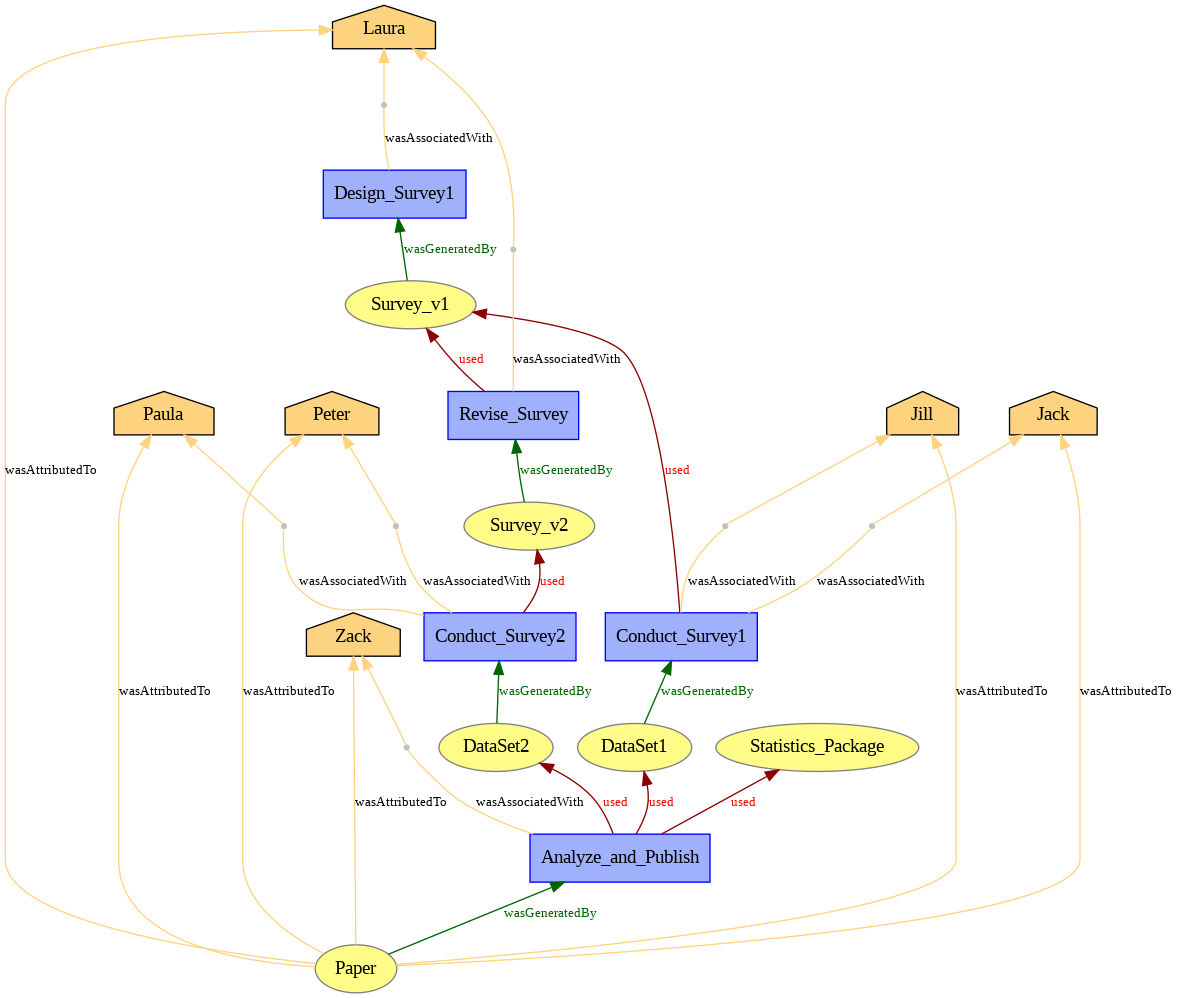

In [14]:
from prov.model import ProvDocument
from prov.dot import prov_to_dot
from IPython.display import Image, display

d = ProvDocument()
d.set_default_namespace('http://example.org/')

# Agents
laura = d.agent('Laura')
jack = d.agent('Jack')
jill = d.agent('Jill')
peter = d.agent('Peter')
paula = d.agent('Paula')
zack = d.agent('Zack')

# Entities
survey_v1 = d.entity('Survey_v1')
survey_v2 = d.entity('Survey_v2')
data_1 = d.entity('DataSet1')
data_2 = d.entity('DataSet2')
stat_pack = d.entity('Statistics_Package')
Paper = d.entity('Paper')

# Activities
design_1 = d.activity('Design_Survey1')
conduct_1 = d.activity('Conduct_Survey1')
revise = d.activity('Revise_Survey')
conduct_2 = d.activity('Conduct_Survey2')
analyze = d.activity('Analyze_and_Publish')

# Relations

d.wasAssociatedWith(design_1, laura)
d.wasGeneratedBy(survey_v1, design_1)

d.wasAssociatedWith(conduct_1, jack)
d.wasAssociatedWith(conduct_1, jill)
d.used(conduct_1, survey_v1)
d.wasGeneratedBy(data_1, conduct_1)

d.wasAssociatedWith(revise, laura)
d.used(revise, survey_v1)
d.wasGeneratedBy(survey_v2, revise)

d.wasAssociatedWith(conduct_2, peter)
d.wasAssociatedWith(conduct_2, paula)
d.used(conduct_2, survey_v2)
d.wasGeneratedBy(data_2, conduct_2)

d.wasAssociatedWith(analyze, zack)
d.used(analyze, data_1)
d.used(analyze, data_2)
d.used(analyze, stat_pack)
d.wasGeneratedBy(Paper, analyze)

d.wasAttributedTo(Paper, zack)
d.wasAttributedTo(Paper, laura)
d.wasAttributedTo(Paper, jack)
d.wasAttributedTo(Paper, jill)
d.wasAttributedTo(Paper, peter)
d.wasAttributedTo(Paper, paula)

# VISUALIZACIÓN
dot = prov_to_dot(d)

diagrama = 'diagrama.png'
dot.write_png(diagrama)
display(Image(diagrama))